# imports

In [1]:
import numpy as numpy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# load data

In [2]:
# src : https://www.kaggle.com/datasets/jahaidulislam/car-specification-dataset-1945-2020?select=Car+Dataset+1945-2020.csv
df = pd.read_csv("res/car-dataset-1945-2020.csv")
df['city_fuel_per_100km_l'].isnull().sum()

#Car with the highest hp
df['engine_hp'].idxmax()
df.loc[df['engine_hp'].idxmax()]



C:\Users\sebas\AppData\Local\Temp\ipykernel_9180\1140561735.py:2: DtypeWarning: Columns (0: load_height_mm, 1: length_mm, 2: width_mm, 3: height_mm, 4: wheelbase_mm, 5: front_track_mm, 6: rear_track_mm, 7: curb_weight_kg, 8: ground_clearance_mm, 9: trailer_load_with_brakes_kg, 10: clearance_mm, 11: max_trunk_capacity_l, 12: cargo_volume_m3, 13: overhead_camshaft, 14: cylinder_bore_and_stroke_cycle_mm, 15: turnover_of_maximum_torque_rpm, 16: capacity_cm3, 17: engine_hp_rpm, 18: bore_stroke_ratio, 19: steering_type, 20: battery_capacity_KW_per_h, 21: charging_time_h) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("res/car-dataset-1945-2020.csv")


id_trim                             53323
Make                                Rimac
Modle                               C Two
Generation                   1 generation
Year_from                          2018.0
                                 ...     
safety_assessment                     NaN
rating_name                           NaN
battery_capacity_KW_per_h             NaN
electric_range_km                     NaN
charging_time_h                       NaN
Name: 53199, Length: 78, dtype: object

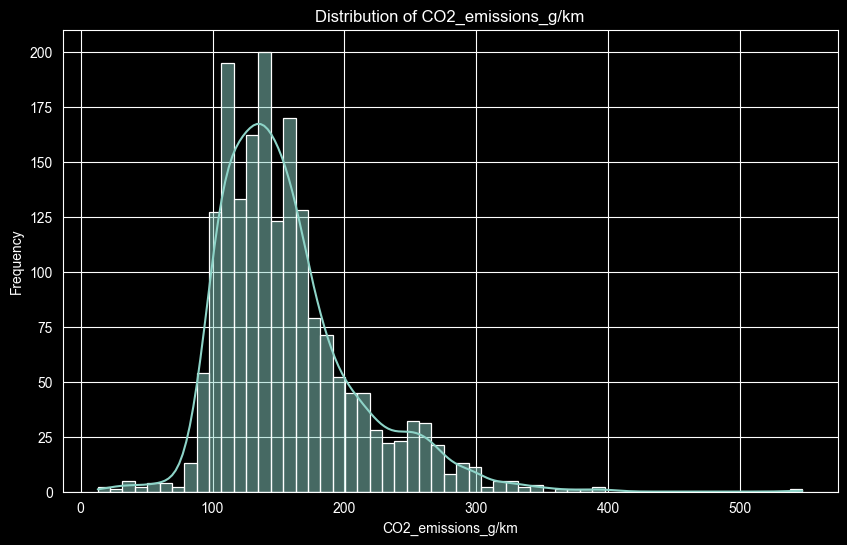

In [3]:
column = 'CO2_emissions_g/km'

plt.figure(figsize=(10, 6))
sns.histplot(df[column].dropna(), kde=True)
plt.title(f'Distribution of {column}')
plt.xlabel(column)
plt.ylabel('Frequency')
plt.show()

#type(df['number_of_seats'].head(1)[0])
#df[column].between(0, 500).sum()


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70823 entries, 0 to 70822
Data columns (total 78 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   id_trim                                   70823 non-null  int64  
 1   Make                                      70823 non-null  str    
 2   Modle                                     70823 non-null  str    
 3   Generation                                70819 non-null  str    
 4   Year_from                                 70586 non-null  float64
 5   Year_to                                   70189 non-null  float64
 6   Series                                    70823 non-null  str    
 7   Trim                                      70823 non-null  str    
 8   Body_type                                 52252 non-null  str    
 9   load_height_mm                            3363 non-null   object 
 10  number_of_seats                           646

# preprocessing

In [5]:
# Remove unnecessary columns and rename selected columns

columns_to_keep = [
    # Main
    "Make",
    "Modle",
    "Year_from",
    "Year_to",
    "Body_type",
    "car_class",
    "number_of_seats",

    # Engine
    "engine_type",
    "capacity_cm3",
    "engine_hp",
    "maximum_torque_n_m",
    "number_of_cylinders",
    "cylinder_layout",

    # Weight
    "curb_weight_kg",

    # Consumption
    "mixed_fuel_consumption_per_100_km_l",
    "city_fuel_per_100km_l",
    "highway_fuel_per_100km_l",
    "CO2_emissions_g/km",
    "emission_standards",
    "range_km",
    "fuel_grade",

    # Performance
    "acceleration_0_100_km/h_s",
    "max_speed_km_per_h",
]

df = df.loc[:, columns_to_keep].rename(
    columns={
        "Make": "manufacturer",
        "Modle": "model",
        "Year_from": "year_from",
        "Year_to": "year_to",
        "Body_type": "body_type",
        "car_class": "car_class",
        "CO2_emissions_g/km": "co2_emissions_g_per_km",
        "acceleration_0_100_km/h_s": "acceleration_0_100_km_h_s",
    }
)
df

,manufacturer,model,year_from,year_to,body_type,car_class,number_of_seats,engine_type,capacity_cm3,engine_hp,...,curb_weight_kg,mixed_fuel_consumption_per_100_km_l,city_fuel_per_100km_l,highway_fuel_per_100km_l,co2_emissions_g_per_km,emission_standards,range_km,fuel_grade,acceleration_0_100_km_h_s,max_speed_km_per_h
0,AC,ACE,1993.0,2000.0,Cabriolet,NaN,2,Gasoline,3505.0,354.0,...,1510.0,NaN,20.0,9.0,NaN,NaN,"450|1,000",95,5.0,250
1,AC,ACE,1993.0,2000.0,Cabriolet,NaN,2,Gasoline,4601.0,326.0,...,1510.0,NaN,15.0,10.0,NaN,NaN,600|900,98,5.0,250
2,AC,ACE,1993.0,2000.0,Cabriolet,NaN,2,Gasoline,4942.0,260.0,...,1440.0,8.0,NaN,NaN,NaN,NaN,NaN,95,NaN,225
3,AC,ACE,1993.0,2000.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AC,ACE,1993.0,2000.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70818,ZX,Landmark,2007.0,2009.0,NaN,J,5,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
70819,ZX,Landmark,2007.0,2009.0,NaN,J,5,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
70820,ZX,Landmark,2007.0,2009.0,NaN,J,5,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
70821,ZX,Landmark,2007.0,2009.0,NaN,J,5,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.describe()

,year_from,year_to,engine_hp,number_of_cylinders,mixed_fuel_consumption_per_100_km_l,city_fuel_per_100km_l,highway_fuel_per_100km_l,co2_emissions_g_per_km,acceleration_0_100_km_h_s
count,70586.00000,70189.000000,59877.000000,59544.000000,40566.000000,39043.000000,38769.000000,1829.000000,40181.000000
mean,1997.06524,1913.441978,166.659853,4.972827,8.675676,11.081615,6.985210,156.235648,10.676648
std,14.99201,415.392957,93.269952,1.585268,3.854646,4.477495,2.719996,51.822704,3.608049
min,1904.00000,0.000000,5.000000,1.000000,0.600000,2.100000,2.100000,13.000000,1.970000
25%,1988.00000,1994.000000,105.000000,4.000000,6.200000,8.000000,5.200000,120.000000,8.300000
50%,2000.00000,2005.000000,141.000000,4.000000,7.900000,10.300000,6.300000,146.000000,10.500000
75%,2008.00000,2013.000000,203.000000,6.000000,9.900000,13.100000,8.000000,178.000000,12.500000
max,2020.00000,2020.000000,1914.000000,16.000000,36.500000,43.100000,28.000000,547.000000,50.000000


In [7]:
# Numeric cleaning

# 1. "range_km" stores "city|highway" with thousands separators, e.g. "450|1,000"
range_parts = df["range_km"].astype(str).str.split("|", expand=True)
df["range_city_km"] = pd.to_numeric(
    range_parts[0].str.replace(",", "", regex=False), errors="coerce"
)
df["range_highway_km"] = pd.to_numeric(
    range_parts[1].str.replace(",", "", regex=False), errors="coerce"
)
df = df.drop(columns=["range_km"])

# 2. some columns use "," as a separator, e.g. "157,4" == 157.4, we replace by point only
decimal_comma_cols = [
    "capacity_cm3",
    "maximum_torque_n_m",
    "curb_weight_kg",
    "max_speed_km_per_h",
]
for col in decimal_comma_cols:
    df[col] = pd.to_numeric(
        df[col].astype(str).str.replace(",", ".", regex=False),
        errors="coerce",
    )

# 3. "number_of_seats" stores multi-config as a list, e.g. "5, 7" (5 or 7 seater), we take the max
seats = df["number_of_seats"].astype(str).str.split(",", expand=True)
df["number_of_seats"] = seats.apply(pd.to_numeric, errors="coerce").max(axis=1)

# Other purely-numeric columns
plain_numeric_cols = [
    "year_from",
    "year_to",
    "engine_hp",
    "number_of_cylinders",
    "mixed_fuel_consumption_per_100_km_l",
    "city_fuel_per_100km_l",
    "highway_fuel_per_100km_l",
    "co2_emissions_g_per_km",
    "acceleration_0_100_km_h_s",
]
df[plain_numeric_cols] = df[plain_numeric_cols].apply(pd.to_numeric, errors="coerce")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70823 entries, 0 to 70822
Data columns (total 24 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   manufacturer                         70823 non-null  str    
 1   model                                70823 non-null  str    
 2   year_from                            70586 non-null  float64
 3   year_to                              70189 non-null  float64
 4   body_type                            52252 non-null  str    
 5   car_class                            11765 non-null  str    
 6   number_of_seats                      64597 non-null  float64
 7   engine_type                          59878 non-null  str    
 8   capacity_cm3                         59837 non-null  float64
 9   engine_hp                            59877 non-null  float64
 10  maximum_torque_n_m                   59518 non-null  float64
 11  number_of_cylinders                  59

In [8]:
df.head(50)

,manufacturer,model,year_from,year_to,body_type,car_class,number_of_seats,engine_type,capacity_cm3,engine_hp,...,mixed_fuel_consumption_per_100_km_l,city_fuel_per_100km_l,highway_fuel_per_100km_l,co2_emissions_g_per_km,emission_standards,fuel_grade,acceleration_0_100_km_h_s,max_speed_km_per_h,range_city_km,range_highway_km
0,AC,ACE,1993.0,2000.0,Cabriolet,NaN,2.0,Gasoline,3505.0,354.0,...,NaN,20.0,9.0,NaN,NaN,95,5.0,250.0,450.0,1000.0
1,AC,ACE,1993.0,2000.0,Cabriolet,NaN,2.0,Gasoline,4601.0,326.0,...,NaN,15.0,10.0,NaN,NaN,98,5.0,250.0,600.0,900.0
2,AC,ACE,1993.0,2000.0,Cabriolet,NaN,2.0,Gasoline,4942.0,260.0,...,8.0,NaN,NaN,NaN,NaN,95,NaN,225.0,NaN,NaN
3,AC,ACE,1993.0,2000.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AC,ACE,1993.0,2000.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,AC,ACE,1993.0,2000.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,AC,ACE,1993.0,2000.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,AC,ACE,1993.0,2000.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,AC,ACE,1993.0,2000.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,AC,Aceca,1998.0,2001.0,Coupe,NaN,4.0,Gasoline,3506.0,354.0,...,13.4,20.0,9.0,NaN,NaN,95,5.6,250.0,350.0,780.0


In [9]:
# normalize categorical text columns (case + variant spellings)
df["engine_type"] = (
    df["engine_type"]
    .str.lower()
    .replace({"petrol": "gasoline", "diesel fuel": "diesel"})
)

df["cylinder_layout"] = (
    df["cylinder_layout"].str.lower().replace({"-": pd.NA})
)

df["body_type"] = df["body_type"].str.lower()

# emission_standards: unify Roman ("EURO IV") and Arabic ("Euro 4") variants
euro_map = {
    "EURO I": "EURO 1", "EURO II": "EURO 2", "EURO III": "EURO 3",
    "EURO IV": "EURO 4", "EURO V": "EURO 5", "EURO VI": "EURO 6",
    "Euro 2": "EURO 2", "Euro 3": "EURO 3", "Euro 4": "EURO 4",
    "Euro 5": "EURO 5", "Euro 6": "EURO 6",
}
df["emission_standards"] = df["emission_standards"].replace(euro_map)

# fuel_grade: take first listed value (most rows have a single octane like "95")
df["fuel_grade"] = (
    df["fuel_grade"].str.split(",").str[0].str.strip().str.lower()
)

df[["engine_type", "cylinder_layout", "body_type", "emission_standards", "fuel_grade"]].nunique()

engine_type           10
cylinder_layout        8
body_type             15
emission_standards     6
fuel_grade            11
dtype: int64

In [10]:
# Check missing values
df.dropna(how="any")

,manufacturer,model,year_from,year_to,body_type,car_class,number_of_seats,engine_type,capacity_cm3,engine_hp,...,mixed_fuel_consumption_per_100_km_l,city_fuel_per_100km_l,highway_fuel_per_100km_l,co2_emissions_g_per_km,emission_standards,fuel_grade,acceleration_0_100_km_h_s,max_speed_km_per_h,range_city_km,range_highway_km


# efficiency ratios

In [11]:
df["hp_per_fuel"] = df["engine_hp"] / df["mixed_fuel_consumption_per_100_km_l"]
df["co2_per_hp"] = df["co2_emissions_g_per_km"] / df["engine_hp"]
df["fuel_per_weight"] = df["mixed_fuel_consumption_per_100_km_l"] / df["curb_weight_kg"]
df['power_density'] = df['engine_hp'] / df['capacity_cm3']
df['weight_power_ratio'] = df['engine_hp'] / df['curb_weight_kg']
df['city_highway_ratio'] = df['city_fuel_per_100km_l'] / df['highway_fuel_per_100km_l']
df['co2_per_seat'] = df['co2_emissions_g_per_km'] / df['number_of_seats']


emission_factor_g_per_l = df['engine_type'].map({'gasoline': 2310, 'diesel': 2650})
df['estimated_co2_g_per_km'] = (
    df['mixed_fuel_consumption_per_100_km_l'] / 100 * emission_factor_g_per_l
)

# HP per cylinder power extracted per combustion chamber.
df['hp_per_cylinder'] = df['engine_hp'] / df['number_of_cylinders']

df[[
    "manufacturer", "model", "year_from",
    "engine_hp", "mixed_fuel_consumption_per_100_km_l",
    "curb_weight_kg", "co2_emissions_g_per_km",
    "hp_per_fuel", "co2_per_hp", "fuel_per_weight",
    "power_density", "weight_power_ratio", "city_highway_ratio", "co2_per_seat",
    "estimated_co2_g_per_km", "hp_per_cylinder",
]].head()

,manufacturer,model,year_from,engine_hp,mixed_fuel_consumption_per_100_km_l,curb_weight_kg,co2_emissions_g_per_km,hp_per_fuel,co2_per_hp,fuel_per_weight,power_density,weight_power_ratio,city_highway_ratio,co2_per_seat,estimated_co2_g_per_km,hp_per_cylinder
0,AC,ACE,1993.0,354.0,NaN,1510.0,NaN,NaN,NaN,NaN,0.100999,0.234437,2.222222,NaN,NaN,44.25
1,AC,ACE,1993.0,326.0,NaN,1510.0,NaN,NaN,NaN,NaN,0.070854,0.215894,1.500000,NaN,NaN,40.75
2,AC,ACE,1993.0,260.0,8.0,1440.0,NaN,32.5,NaN,0.005556,0.052610,0.180556,NaN,NaN,184.8,32.50
3,AC,ACE,1993.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AC,ACE,1993.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# plots

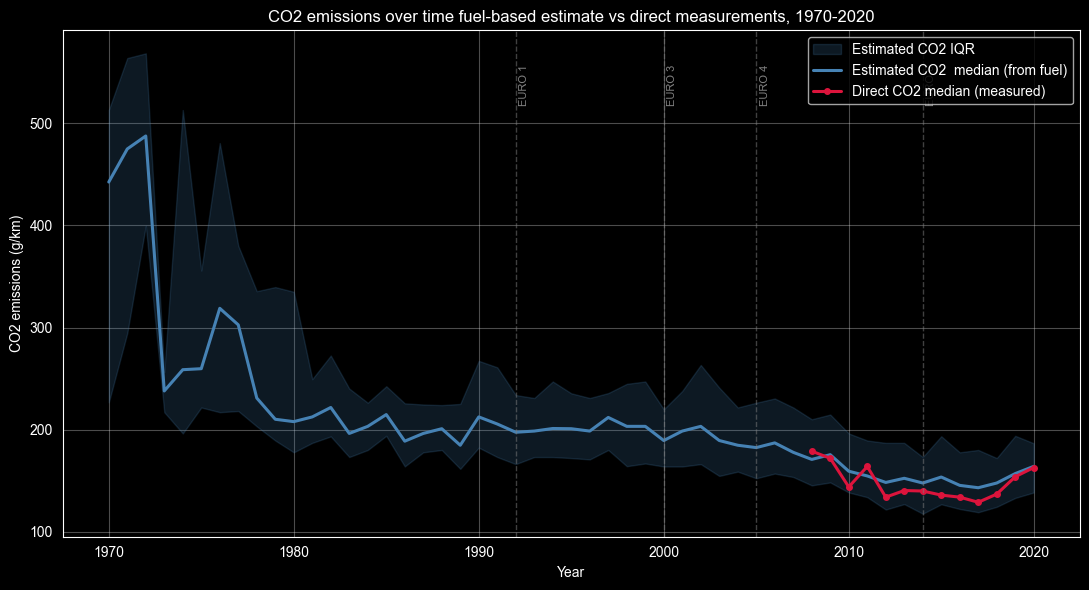

Median ratio (est/dir) across overlap: 1.079


In [12]:
mask_est = df['year_from'].between(1970, 2020) & df['estimated_co2_g_per_km'].notna()
yearly_est = (df.loc[mask_est].groupby('year_from')['estimated_co2_g_per_km']
              .agg(median='median', q25=lambda s: s.quantile(0.25),
                   q75=lambda s: s.quantile(0.75), n='count').reset_index())
yearly_est = yearly_est[yearly_est['n'] >= 20]

mask_dir = df['year_from'].between(1970, 2020) & df['co2_emissions_g_per_km'].notna()
yearly_dir = (df.loc[mask_dir].groupby('year_from')['co2_emissions_g_per_km']
              .agg(median='median', n='count').reset_index())
yearly_dir = yearly_dir[yearly_dir['n'] >= 20]

fig, ax = plt.subplots(figsize=(11, 6))
ax.fill_between(yearly_est['year_from'], yearly_est['q25'], yearly_est['q75'],
                alpha=0.2, color='steelblue', label='Estimated CO2 IQR')
ax.plot(yearly_est['year_from'], yearly_est['median'], linewidth=2.2, color='steelblue',
        label='Estimated CO2  median (from fuel)')
ax.plot(yearly_dir['year_from'], yearly_dir['median'], linewidth=2.2, color='crimson',
        marker='o', markersize=4, label='Direct CO2 median (measured)')
for name, year in {'EURO 1':1992,'EURO 3':2000,'EURO 4':2005,'EURO 6':2014}.items():
    ax.axvline(year, color='grey', linestyle='--', alpha=0.5, linewidth=1)
    ax.text(year+0.2, yearly_est['q75'].max()*0.98, name, rotation=90, fontsize=8, color='grey', va='top')
ax.set_xlabel('Year'); ax.set_ylabel('CO2 emissions (g/km)')
ax.set_title('CO2 emissions over time fuel-based estimate vs direct measurements, 1970-2020')
ax.legend(loc='upper right'); ax.grid(True, alpha=0.3); plt.tight_layout()
plt.show()

overlap = yearly_est.merge(yearly_dir, on='year_from', suffixes=('_est','_dir'))
overlap['ratio'] = overlap['median_est']/overlap['median_dir']
print(f"Median ratio (est/dir) across overlap: {overlap['ratio'].median():.3f}")

## Sample composition

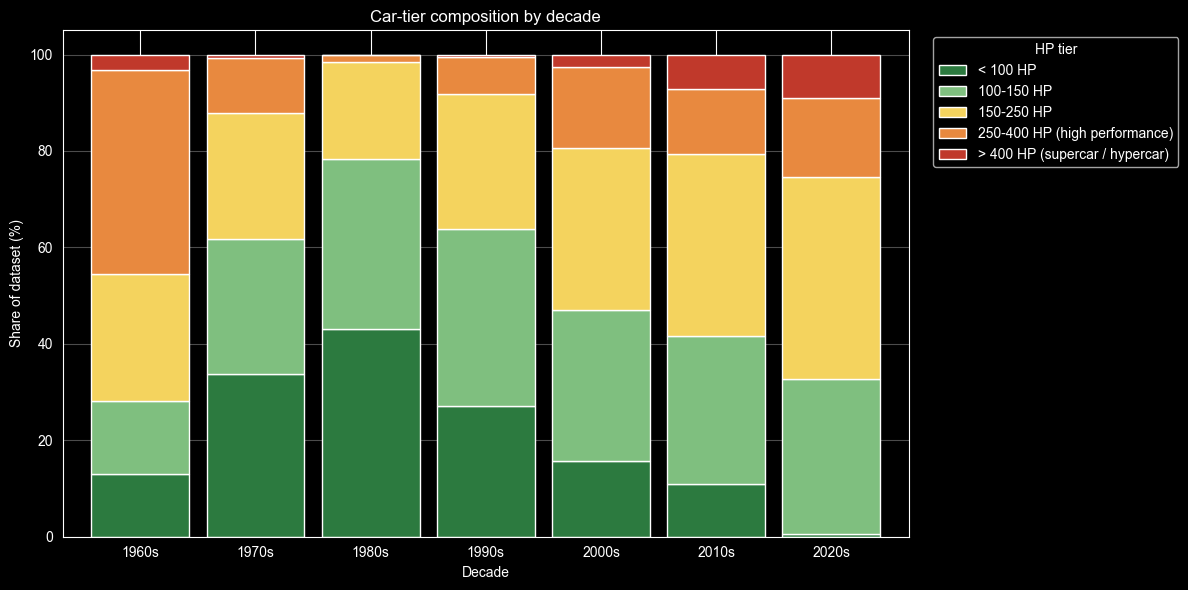

Share of >250 HP cars per decade :
decade
1960s    45.4
1970s    12.1
1980s     1.6
1990s     8.2
2000s    19.3
2010s    20.6
2020s    25.4

Number of cars per decade:
decade
1960s     3556
1970s     3783
1980s     6885
1990s    13370
2000s    19065
2010s    12595
2020s      189


In [13]:
hp_bins = [0, 100, 150, 250, 400, 1e6]
hp_labels = [
    '< 100 HP ',
    '100-150 HP ',
    '150-250 HP ',
    '250-400 HP (high performance)',
    '> 400 HP (supercar / hypercar)',
]
mask = df['engine_hp'].notna() & df['year_from'].between(1960, 2020)
plot_df = df.loc[mask, ['year_from', 'engine_hp']].copy()
plot_df['decade'] = (plot_df['year_from'] // 10 * 10).astype(int).astype(str) + 's'
plot_df['hp_tier'] = pd.cut(plot_df['engine_hp'], bins=hp_bins, labels=hp_labels, right=False)

counts = (plot_df.groupby(['decade', 'hp_tier'], observed=True).size()
          .unstack(fill_value=0).reindex(columns=hp_labels, fill_value=0))
share = counts.div(counts.sum(axis=1), axis=0) * 100
decade_n = counts.sum(axis=1)

fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#2c7a3f', '#7fbf7f', '#f4d35e', '#e8893f', '#c0392b']

share.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=colors,
    width=0.85
)

ax.set_xlabel('Decade')
ax.set_ylabel('Share of dataset (%)')

ax.set_title(
    'Car-tier composition by decade'
)

ax.set_ylim(0, 105)

ax.legend(
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    title='HP tier'
)

ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=0)


plt.tight_layout()
plt.show()

print("Share of >250 HP cars per decade :")
print(share[['250-400 HP (high performance)', '> 400 HP (supercar / hypercar)']]
      .sum(axis=1).round(1).to_string())
print("\nNumber of cars per decade:")
print(decade_n.to_string())
